<h2>Assigment 3 (Shor's Algorithm)</h2>
In this assignment, we will work through the disparate parts of Shor's algorithm to run through the various parts of the algorithm that were not clearly explored in our lectures.
Note that the problems build upon each other. You will have to solve a previous problem to move on to the next part.

<h4>Problem 1</h4>
Suppose we are interested in factoring the number  77 which we know as  11×7 (hence p=11, q=7) using a quantum computer and choose  𝑎=4 as our number which is relatively prime to 11.
We construct the quantum circuit that implements the function

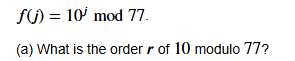

My answers -
<p />

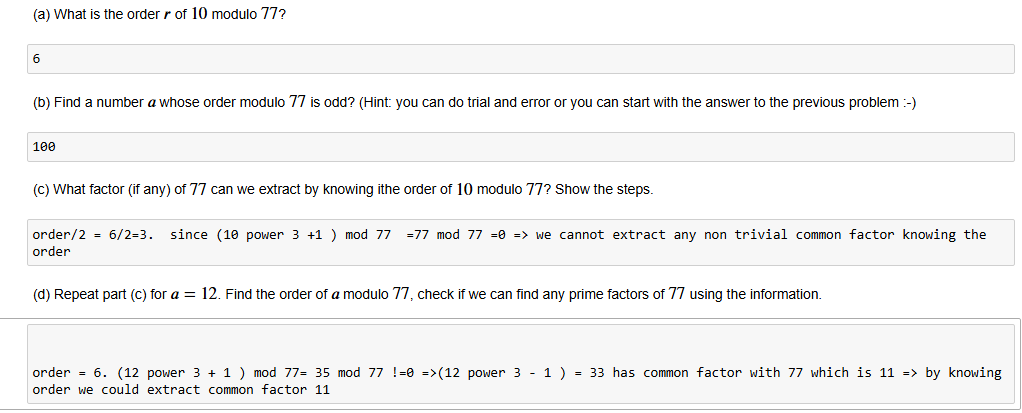
<p />
which were all correct answers as given at the end of the exercise

<p />
(e) Implement a classical function to find the order of  𝑎   modulo  𝑛   where  𝑎,𝑛   are inputs.


In [1]:
def find_order(a, n):
    # your code here
    power = 1
    iter = 1
    result = ((a**power) % n)
    while(result != 1):
        result = (result*a) % n
        iter += 1
    return iter

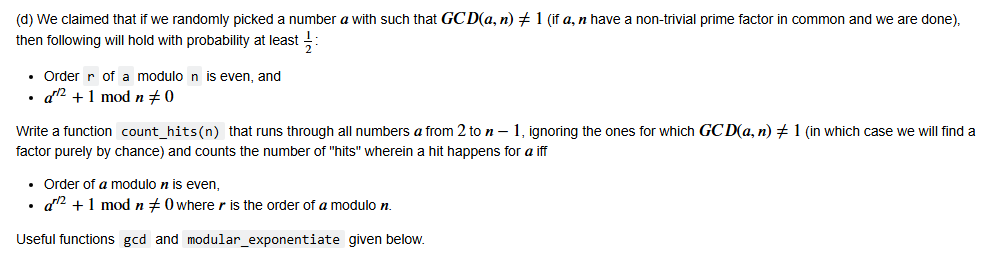

In [2]:
def gcd(m, n):
    (m, n) = max(m, n), min(m, n)
    assert m > 0
    assert n >= 0
    while n > 0:
        (m, n) = (n, m%n)
    return m

def modular_exponentiate(a, k, n): # a^k \mod n
    m = a
    j = 0
    res = 1
    while k > 0:
        if k % 2 == 1:
            res = (res * m) % n
        
        m = (m * m) % n
        j = j + 1
        k = k // 2
    return res


In [5]:
def count_hits(n):
    # your code here
    hits = 0
    hit_numbers = []
    for a in range(2,n):
        if gcd(a,n) != 1 :
            continue
        order = find_order(a,n)
        mo_ex = modular_exponentiate(a, order/2, n) # a^k \mod n
        mo_ex = (mo_ex + 1 ) % n # (a^k +1 ) \mod n = (a^k \mod n + 1 \mod n ) \mod n
        hits = hits + (1 if order % 2 ==0 and mo_ex!=0  else 0)   
        hit_numbers.append(a)
    return hits 

In [7]:
h15 = count_hits(15)
print(f'count_hits(15) = {h15}')
assert h15 == 6 # hits for 15 are 2, 4, 7, 8, 11, 13
# note that \varphi(15) = 2 * 4 = 8
print(f'Fraction of hits among relatively prime = {h15/(2*4)}')

h77 = count_hits(77) # there should be 46 hits for 77
print(f'count_hits(77) = {h77}')
assert h77 == 30
# note that \varphi(77) = 6 * 10 = 60
print(f'Fraction of hits among relatively prime = {h77/(60)}')


h91 = count_hits(91)
print(f'count_hits(91) = {h91}')
assert h91 == 54
# note \varphi(91) = 12 * 6 = 72
print(f'Fraction of hits among relatively prime = {h91/(72)}')

h111 = count_hits(111) # there whould be 92 hits
print(f'count_hits(111) = {h111}')
assert h111 == 54
# note \varphi(111) = 36 * 2 = 72
print(f'Fraction of hits among relatively prime = {h111/(72)}')


h893 = count_hits(893)
print(f'count_hits(893) = {h893}')
assert h893 == 414


count_hits(15) = 6
Fraction of hits among relatively prime = 0.75
count_hits(77) = 30
Fraction of hits among relatively prime = 0.5
count_hits(91) = 54
Fraction of hits among relatively prime = 0.75
count_hits(111) = 54
Fraction of hits among relatively prime = 0.75
count_hits(893) = 414


Hopefully the above code will show at least empirically (if the proof given in our notes was too much for you), that a random choice of a has a high probability of helping us find a non-trivial factor of n if we can compute its order fast.

<h2>Problem 2</h2>

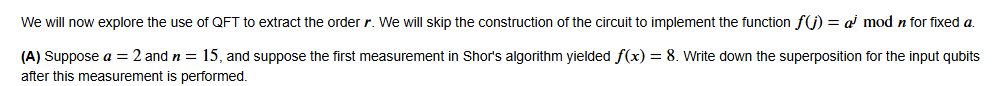

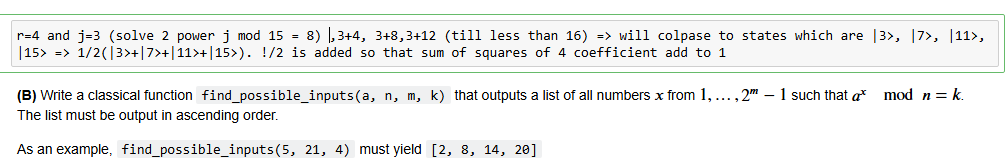

In [13]:
def find_possible_inputs(a, n, k, m):
    # your code here
    response = []
    for y in range(1,2**m):
        if (a**y)%n == k:
            response.append(y)
    return response

In [14]:
lst1 = find_possible_inputs(5, 21, 4, 5)
print('lst1 =', lst1)
assert lst1 == [2, 8, 14, 20, 26]
lst2 = find_possible_inputs(2, 15, 8, 4)
print('lst2 = ', lst2)
assert(lst2 == [3, 7, 11, 15])
lst3 = find_possible_inputs(3, 77, 4, 7)
print('lst3 = ', lst3)
assert lst3 == [4, 34, 64, 94, 124]
lst4 = find_possible_inputs(5, 91, 79, 7)
print('lst4 = ', lst4)
assert lst4 == [4, 16, 28, 40, 52, 64, 76, 88, 100, 112, 124]

lst1 = [2, 8, 14, 20, 26]
lst2 =  [3, 7, 11, 15]
lst3 =  [4, 34, 64, 94, 124]
lst4 =  [4, 16, 28, 40, 52, 64, 76, 88, 100, 112, 124]


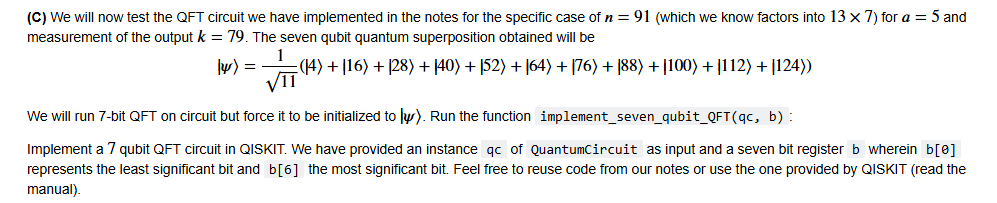

In [22]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import QFT
from numpy import pi

def implement_seven_qubit_QFT(qc, b):
    assert len(b) == 7
    # assume b is a seven qubit quantum register as an input
    # your code here
    qc.append(QFT(num_qubits=7, approximation_degree=0, do_swaps=True, inverse=False, insert_barriers=True, name='qft7bit'), b)
    

initial super position is :  [0.0, 0.0, 0.0, 0.0, np.float64(0.30151134457776363), 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, np.float64(0.30151134457776363), 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, np.float64(0.30151134457776363), 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, np.float64(0.30151134457776363), 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, np.float64(0.30151134457776363), 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, np.float64(0.30151134457776363), 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, np.float64(0.30151134457776363), 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, np.float64(0.30151134457776363), 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, np.float64(0.30151134457776363), 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, np.float64(0.30151134457776363), 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, np.float64(0.30151134457776363), 0.0, 0.0, 0.0]


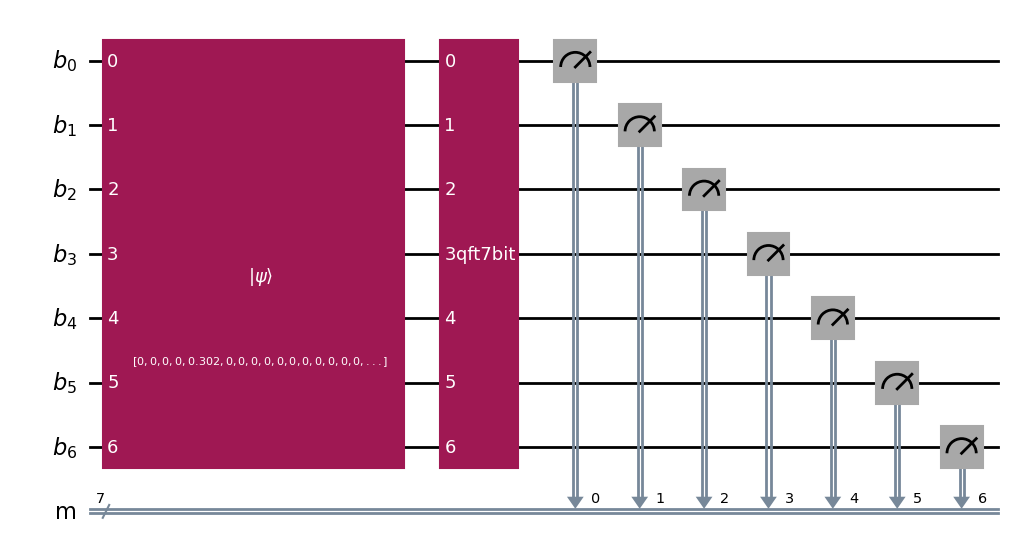

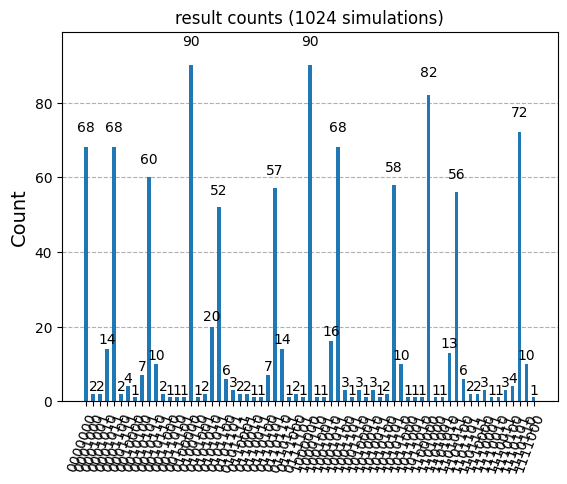

 Measurements obtained 75% of the time.
	 Measurement 64 is obtained with probability 0.087890625
		 64 * 12/2^7 = 6.0
	 Measurement 32 is obtained with probability 0.087890625
		 32 * 12/2^7 = 3.0
	 Measurement 96 is obtained with probability 0.080078125
		 96 * 12/2^7 = 9.0
	 Measurement 117 is obtained with probability 0.0703125
		 117 * 12/2^7 = 10.96875
	 Measurement 75 is obtained with probability 0.06640625
		 75 * 12/2^7 = 7.03125
	 Measurement 11 is obtained with probability 0.06640625
		 11 * 12/2^7 = 1.03125
	 Measurement 0 is obtained with probability 0.06640625
		 0 * 12/2^7 = 0.0
	 Measurement 21 is obtained with probability 0.05859375
		 21 * 12/2^7 = 1.96875
	 Measurement 85 is obtained with probability 0.056640625
		 85 * 12/2^7 = 7.96875
	 Measurement 53 is obtained with probability 0.0556640625
		 53 * 12/2^7 = 4.96875
	 Measurement 107 is obtained with probability 0.0546875
		 107 * 12/2^7 = 10.03125


In [23]:
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit import transpile 
from qiskit_aer import Aer
from numpy import pi, sqrt
from qiskit.visualization import plot_histogram

b = QuantumRegister(7, 'b')
m_out = ClassicalRegister(7, 'm')
qc = QuantumCircuit(b, m_out)
lst = [4, 16, 28, 40, 52, 64, 76, 88, 100, 112, 124]
c = 1.0/sqrt(len(lst))
state_vector = [c if i in lst else 0.0 for i in range(128)]
print('initial super position is : ', state_vector)
qc.initialize(state_vector, b)
implement_seven_qubit_QFT(qc, b)
qc.measure(b, m_out)
display(qc.draw('mpl', style='iqp'))
# Let's run this circuit and see what we get 
simulator = Aer.get_backend('aer_simulator')
circ = transpile(qc, simulator)
result = simulator.run(circ).result()
counts = result.get_counts(circ)
display(plot_histogram(counts, title='result counts (1024 simulations)'))
res_list=[(0,0) ]*1024
#print(counts)
for (k, v) in counts.items():
    j = int(k, 2)
    res_list[j] = (v/1024, j)
res_list.sort(reverse=True)
sum = 0.0
j = 0
print(' Measurements obtained 75% of the time.')
while sum <= 0.75:
    sum = sum + res_list[j][0]
    print(f'\t Measurement {res_list[j][1]} is obtained with probability {res_list[j][0]}')
    meas = res_list[j][1]
    # test that meas * r/2^m is very close to an integer. Here we know r = 12 (secretly) and m = 7 qubits
    print(f'\t\t {meas} * 12/2^7 = {meas * 12/2**7}')
    j = j + 1

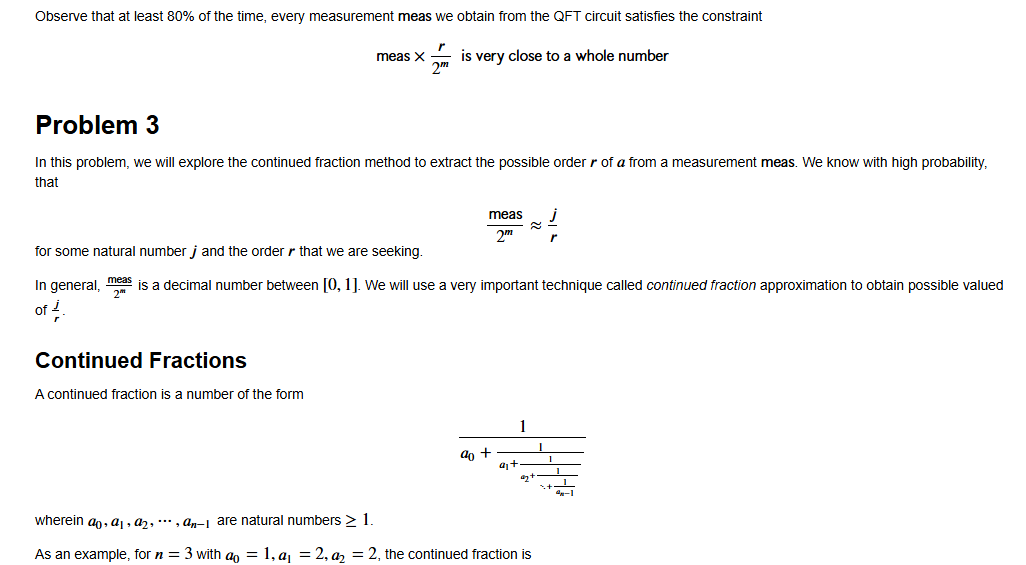
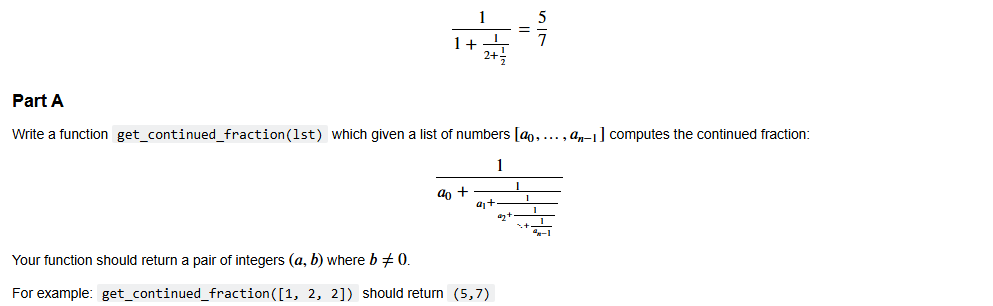

In [ ]:
from fractions import Fraction

def get_continued_fraction_recur(lst):
    assert len(lst) >= 1
    # your code here
    if len(lst)==1: # base case
        return 1/(lst[0])
    return 1/(lst[0] + get_continued_fraction_recur(lst[1:]))

def get_continued_fraction(lst):
    response = get_continued_fraction_recur(lst)
    return Fraction(response).limit_denominator(1_000_000).as_integer_ratio()

In [10]:
(n4, d4) = get_continued_fraction([5])
print(f'Test # 0: {n4}/{d4}')
assert n4 == 1 and d4 == 5

(n1, d1) =  get_continued_fraction([1,2,2])
print(f'Test # 1: {n1}/{d1}')
assert n1 == 5 and d1 == 7

(n2, d2) = get_continued_fraction([1, 2, 1, 2, 1])
print(f'Test # 2: {n2}/{d2}')
assert n2 == 11 and d2 == 15

(n3, d3) = get_continued_fraction([1,1,1,1,1,1])
print(f'Test # 3: {n3}/{d3}')
assert n3 == 8 and d3 == 13


Test # 0: 1/5
Test # 1: 5/7
Test # 2: 11/15
Test # 3: 8/13


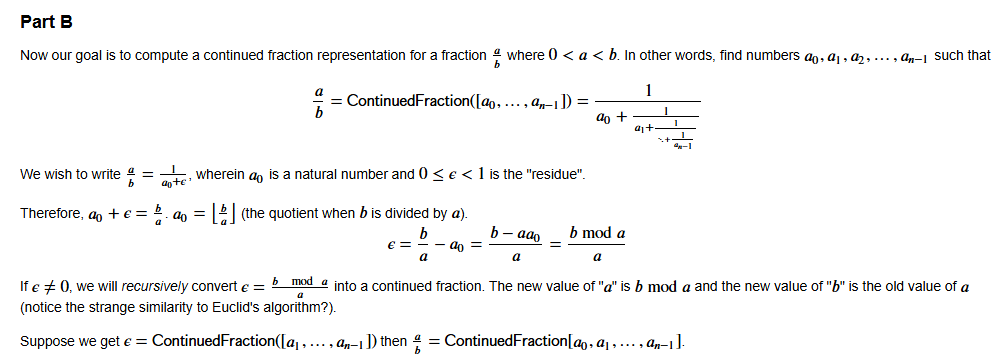
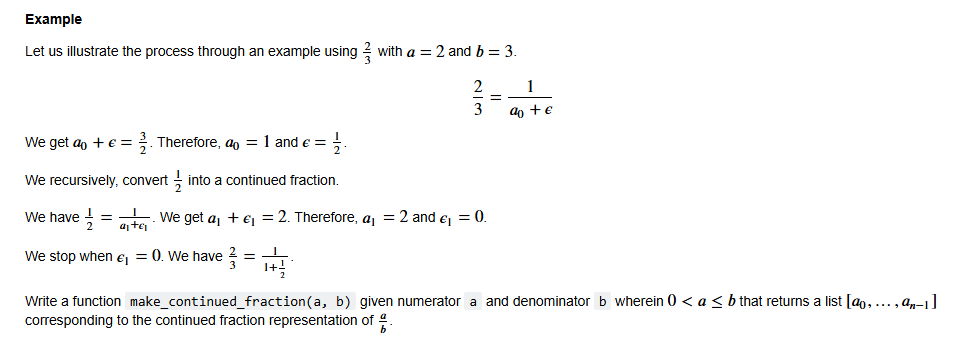

In [28]:
from fractions import Fraction

def make_continued_fraction_recurs(a, b, lst):
    assert a > 0
    assert a <= b
    # your code here
    tmp_lst = Fraction(b/a).limit_denominator(1_000_000).as_integer_ratio()
    if(tmp_lst[1] == 1): #base case
        lst.append(tmp_lst[0])
        return 
    tmp_lst = Fraction((b/a) -1).limit_denominator(1_000_000).as_integer_ratio()
    make_continued_fraction_recur(tmp_lst[0], tmp_lst[1], lst)

def make_continued_fraction_recur(frac):
    frac = Fraction(frac).limit_denominator(1_000_000)
    if frac.denominator == 1:
        return [frac.numerator]
    else:
        ipart, fpart = divmod(frac, 1)
        return [int(ipart)] + make_continued_fraction_recur(1 / fpart)

def make_continued_fraction(a, b):
    assert a > 0
    assert a <= b
    # your code here
    lst = make_continued_fraction_recur(Fraction(a/ b))
    if lst[0] == 0:
        return lst[1:]
    else:
        return lst

In [30]:
f1 = make_continued_fraction(197, 1024) 
print(f'197/1024 = ContinuedFraction({f1})')
assert f1 == [5, 5, 19, 2]

f2 = make_continued_fraction(64, 128) 
print(f'64/128 = ContinuedFraction({f2})')
assert f2 == [2]


f3 = make_continued_fraction(1, 1) 
print(f'1/1 = ContinuedFraction({f3})')
assert f3 == [1]

f4 = make_continued_fraction(314157,1000000)
print(f'314157/1000000 = ContinuedFraction({f4})')
assert f4 == [3, 5, 2, 5, 1, 7, 1, 2, 3, 2, 1, 15]

197/1024 = ContinuedFraction([5, 5, 19, 2])
64/128 = ContinuedFraction([2])
1/1 = ContinuedFraction([1])
314157/1000000 = ContinuedFraction([3, 5, 2, 5, 1, 7, 1, 2, 3, 2, 1, 15])


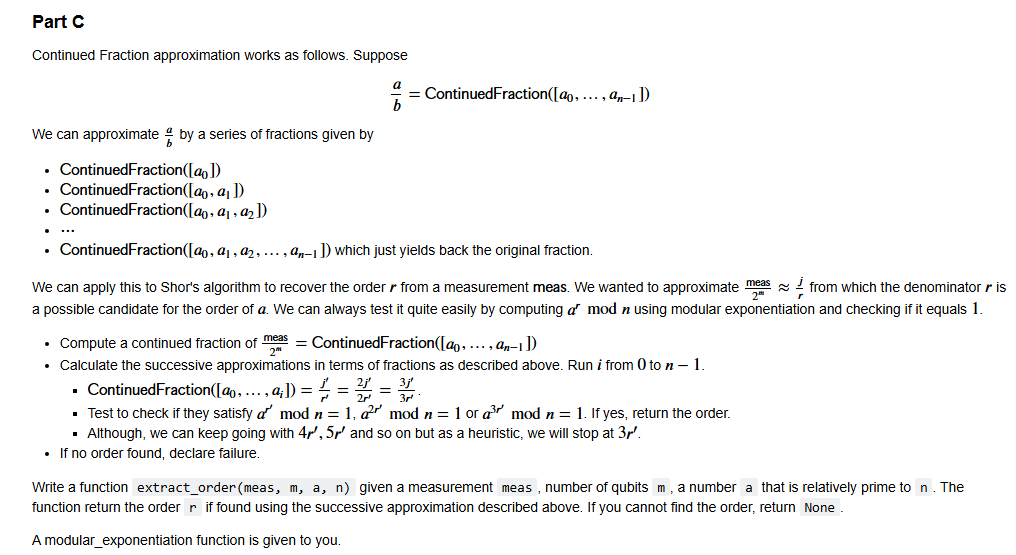

In [31]:
def modular_exponentiate(a, k, n): # a^k \mod n
    mu = a
    res = 1
    while k > 0:
        if k % 2 == 1:
            res = (res * mu) % n   
        mu = (mu * mu) % n
        k = k // 2
        
    return res

In [34]:
def extract_order(meas, m, a, n):
    # your code here
    lst = make_continued_fraction(meas, 2**m)
    for x in range(3):
        lst_tmp = get_continued_fraction(lst[:x])
        if modular_exponentiate(a,k,n) ==1:
            return k
    return None

In [35]:
r1 = extract_order(75, 7, 5, 91)
assert r1 == 12

r2 = extract_order(53, 7, 5, 91)
assert r2 == 12

r3 = extract_order(96, 7, 5, 91)
assert r3 == 12


r4 = extract_order(32, 7, 5, 91)
assert r4 == 12


r5 = extract_order(64, 7, 5, 91)
assert r5 == None



r6 = extract_order(11, 7, 5, 91)
assert r6 == 12


AssertionError: 

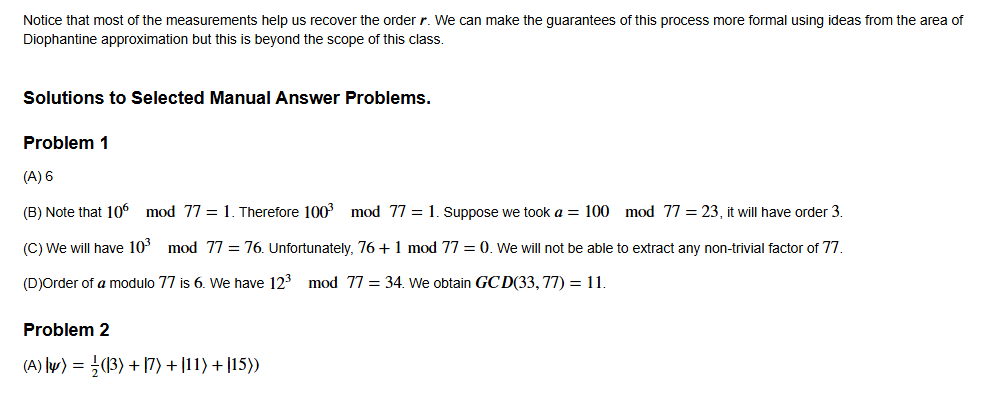